# DAAAnalyzer_2.0.AnalyzeABRs.ipynb
Created by: JFranco | Created On: 27 NOV 2024 | Last Env: QISHA | Last Run Date: 27 NOV 2024

This Python notebook will read in all DPOAE files for a specific DAA Run as specified by the user. It will make a lineplot for all availble files and label them by category. 

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import xlrd
import math
import matplotlib.pyplot as plt

In [2]:
#                *** WHAT TO ANALYZE // WHERE TO GET/STORE **
# Key identifiers
prepID = 'CMI_003'
daaRun = '1'
daaType = 'Pre-Noise Exposure'
isoFile = 'IsoDP-'+daaRun+'-1.tsv'
fnMD = 'CMI_003.Metadata.AnimalInfo.csv'

# Directories 
#   existing ones 
dirMain = '/Users/joyfranco/Dropbox (Partners HealthCare)/JF_Shared/Data/CFTS/'
dirPrep = dirMain+prepID+'/'
dirData = dirPrep+'RawData/'
dirMD = dirPrep+'Metadata/'
pathTest = dirData+prepID+".C016.1/"

#   ones that need to be made    
dirSV = dirPrep+'Results/'        

In [3]:
#    *** LOAD MD SHEETS **
# Sample metadata sheet that include animal and condition info
dfMD = pd.read_csv(dirMD+fnMD)
dfMD.reset_index(inplace=True)
dfMD

,index,AnimalID,Sex,DOB,CMIID,InjectionDate,AgeAtInjection,Package,InjGroup,NE,NEDate,AgeAtNE,NELevel,NEBand,NEDuration,NEGroup
0,0,C016,M,9/24/24,CMI_003,11/11/24,7,AAV,HABclw,Yes,11/25/24,9,97.5,8_16,2h,1
1,1,C017,F,9/24/24,CMI_003,11/11/24,7,AAV,HABclw,Yes,11/25/24,9,97.5,8_16,2h,2
2,2,C018,M,9/24/24,CMI_003,11/11/24,7,AAV,HABclw,Yes,11/25/24,9,97.5,8_16,2h,2
3,3,C019,F,9/24/24,CMI_003,11/11/24,7,AAV,CtrlInj,Yes,11/25/24,9,97.5,8_16,2h,1
4,4,C020,M,9/24/24,CMI_003,11/11/24,7,AAV,CtrlInj,Yes,11/25/24,9,97.5,8_16,2h,1
5,5,C021,F,9/24/24,CMI_003,11/11/24,7,AAV,CtrlInj,Yes,11/25/24,9,97.5,8_16,2h,2
6,6,C022,M,9/24/24,CMI_003,11/11/24,7,AAV,UnInj,Yes,11/25/24,9,97.5,8_16,2h,2
7,7,C023,F,9/24/24,CMI_003,11/11/24,7,AAV,UnInj,Yes,11/25/24,9,97.5,8_16,2h,1


In [4]:
#      *** INITIALIZE RUN SPECIFIC DIRECTORY ETC FOR STORING RESULTS **
# Create directory for storing spreadsheetS and summary plotS for this run
if not os.path.exists(dirSV): os.mkdir(dirSV)

In [5]:
#      *** GENERATE A LIST OF DAA FOLDERS THAT WILL BE ANALYZED **
# Get a list of all the folders that match the prep
allData = os.listdir(dirData)
dataList = []
for datum in allData:
    if ('.'+daaRun) in datum:
        dataList.append(datum)
dataList

['CMI_003.C020.1',
 'CMI_003.C023.1',
 'CMI_003.C016.1',
 'CMI_003.C018.1',
 'CMI_003.C022.1',
 'CMI_003.C017.1',
 'CMI_003.C019.1',
 'CMI_003.C021.1']

In [285]:
#       *** ITERATE THROUGH THE FOLDERS AND PLOT ABR RUNS **
# First plot all of the available levels and frequencies so that the user can identify 
# the threshold for each frequency
dfAll = pd.DataFrame()
for daa in dataList:
    # Setup the path to the file
    abrFold = dirData+daa+'/'
    # Get a list of available ABR files
    allFiles = os.listdir(abrFold)
    anaFiles = []
    dfFAll = pd.DataFrame()
    for file in allFiles:
        # Only consider files that are analyzed 
        if ("analyzed.txt") in file:
            # Get information about the recording subject
            anID = daa[8:-2]
            df['AnimalID'] = anID
            df['CMIID'] = prepID
            df['DAA_Run'] = daaRun
            # Get information about this animal from the MD sheet
            inMD = dfMD.index[dfMD['AnimalID']==anID].tolist()[0]
            inj = dfMD.loc[inMD]['InjGroup']
            sex = dfMD.loc[inMD]['Sex']
            # Get the base filename
            strFile = str(file)
            inPost = strFile.index("analyzed.txt")
            basename = strFile[0:(inPost-1)]
            # Open the analyzed file to get the ABR frequency for this file
            with open(abrFold+basename+"-analyzed.txt", "r") as f:
                anaABR = f.read()
                inPre = anaABR.index("(kHz):")
                inPost = anaABR.index("Threshold estimation:")
                freq = anaABR[(inPre+6):(inPost-2)]
            # Read in the analyzed ABR file 
            dfAA = pd.read_csv(abrFold+basename+"-analyzed.txt", sep="\t", skiprows=6)
            # Read in the filtered ABR file 
            dfFA = pd.read_csv(abrFold+basename+"-filtered.txt", delimiter='\t', header=0,index_col="Time (ms)")
            # Get the number of dB levels for the file
            for level in dfFA.columns:
                # Get the WI amplitudes for this level
                inLV = dfAA.index[dfAA[dfAA.columns[0]]==float(level[0:-3])].tolist()[0]
                waveOne = dfAA.loc[inLV]['P1 Amplitude']
                data = {'AnimalID':anID,"CMIID":prepID,"Sex":sex,"InjGroup":inj,"File":basename,"DAA_Run":daaRun,
                       "Freq_kHz":float(freq),"Level":level, "Time_ms":dfFA.index,"Amp_uV":dfFA[level].values,"P1_Amplitude_uV":waveOne}
                df = pd.DataFrame(data)
                dfFAll = pd.concat([dfFAll,df])
                dfAll = pd.concat([dfAll,df])
    
    # Create a FacetGrid
    pal = sns.cubehelix_palette(len(dfFAll["Level"].unique()), rot=-.25, light=.7)
    g = sns.FacetGrid(dfFAll, col="Freq_kHz",row="Level", aspect=4, height=1, 
                      col_order=np.sort(dfFAll["Freq_kHz"].unique()), row_order=np.sort(dfFAll["Level"].unique())[::-1],hue="Level",palette=pal)
    
    # Plot the density curves
    g.map(sns.lineplot, "Time_ms", "Amp_uV")

    g.refline(y=0, linewidth=.5, linestyle="--", color=None, clip_on=False)
    g.refline(x=2, linewidth=.5, linestyle="--", color=None, clip_on=False)

    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .5, label, fontweight="bold", color=color,
                ha="right", va="center", transform=ax.transAxes)
    g.map(label, "Level")
    
    # Adjust plot aesthetics
    g.set(xlim=(0, 9), ylim=(-1.5, 1.5))
    
    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-.4)
    g.figure.suptitle(prepID+" "+anID+" | "+daaType+"\n"+str(np.sort(dfFAll["Freq_kHz"].unique())), fontsize=12)
    
    # Remove axes details that don't play well with overlap
    #g.set_titles(col_template="{Freq_kHz}")
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.set(xlabel="Time (msec)")
    g.despine(bottom=True, left=True)
    
    # *** SAVE THE FIGURE ***
    plt.savefig(dirSV+prepID+'.'+anID+'.'+daaRun+'.png',  bbox_inches='tight', dpi = 300,format = 'png')
    plt.close()
            
            
dfAll.reset_index(inplace=True)

/usr/local/Caskroom/miniconda/base/envs/QISHA/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/QISHA/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/QISHA/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/QISHA/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/QISHA/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/usr/local/Caskroom/

/usr/local/Caskroom/miniconda/base/envs/QISHA/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/QISHA/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/QISHA/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/usr/local/Caskroom/miniconda/base/envs/QISHA/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


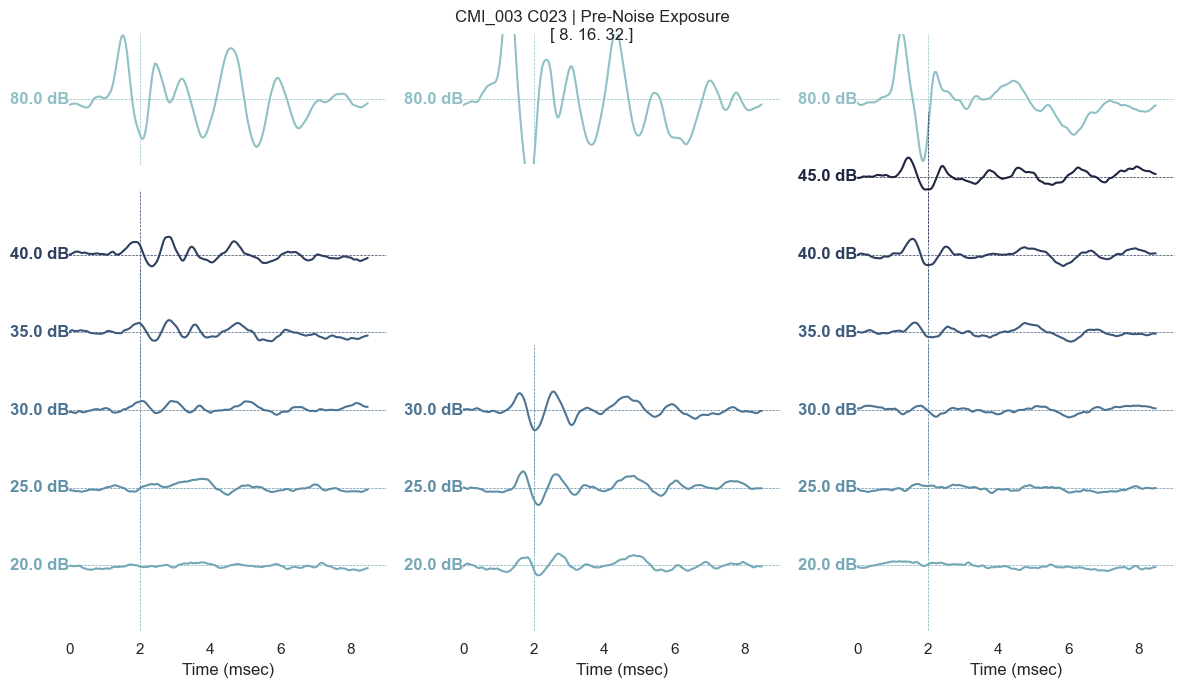

In [284]:

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create a FacetGrid
pal = sns.cubehelix_palette(len(dfFAll["Level"].unique()), rot=-.25, light=.7)
g = sns.FacetGrid(dfFAll, col="Freq_kHz",row="Level", aspect=4, height=1, 
                  col_order=np.sort(dfFAll["Freq_kHz"].unique()), row_order=np.sort(dfFAll["Level"].unique())[::-1],hue="Level",palette=pal)

# Plot the density curves
g.map(sns.lineplot, "Time_ms", "Amp_uV")
plt.axvline(x=22, color="cyan", linestyle="-")

g.refline(y=0, linewidth=.5, linestyle="--", color=None, clip_on=False)
g.refline(x=2, linewidth=.5, linestyle="--", color=None, clip_on=False)

# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .5, label, fontweight="bold", color=color,
            ha="right", va="center", transform=ax.transAxes)
g.map(label, "Level")

# Adjust plot aesthetics
g.set(xlim=(0, 9), ylim=(-1.5, 1.5))

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.4)
g.figure.suptitle(prepID+" "+anID+" | "+daaType+"\n"+str(np.sort(dfFAll["Freq_kHz"].unique())), fontsize=12)

# Remove axes details that don't play well with overlap
#g.set_titles(col_template="{Freq_kHz}")
g.set_titles("")
g.set(yticks=[], ylabel="")
g.set(xlabel="Time (msec)")
g.despine(bottom=True, left=True)

plt.show()

In [265]:
str(dfFAll["Freq_kHz"].unique())

'[ 8. 32. 16.]'

In [187]:
vals = dfFAll["Level"].unique()
test = np.sort(dfFAll["Level"].unique())[::-1]
print(test)

['50.0 dB' '45.0 dB' '40.0 dB' '35.0 dB' '30.0 dB' '25.0 dB' '20.0 dB']


In [151]:
dfAA.index[dfAA[dfAA.columns[0]]==float(level[0:-3])].tolist()[0]

0

In [132]:
df = pd.read_csv(pathTest+fileAnalyzed, sep="\t", skiprows=6) 
df

    ***       
    # Go through the files and make a line plot that contains all ABRs for that frequency
    for file in files:
        # Setup the path to the file
        path = dirData+daa+'/'+file
        # Read in the filtered ABR file
        dfFA = pd.read_csv(path, delimiter='\t', header=0,index_col="Time (ms)")
        # Read in the analyzed ABR file
        dfAA = pd.read_csv(pathTest+fileFiltered, delimiter='\t', header=0,index_col="Time (ms)")
        
        # Convert the information into a df for plotting
        for col in dfFA:
            data = {'f2Freq_kHz': freqs, 'Thresh_dBSPL': threshs}
            df = pd.DataFrame(data)
    ***

IndentationError: unexpected indent (1165704194.py, line 4)

In [266]:
np.sort(dfFAll["Freq_kHz"].unique())

array([ 8., 16., 32.])